# Customer Vulnerablity



# Loading Modules & Data

In [1]:
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Setting environment to ignore future warnings
import warnings
warnings.simplefilter('ignore')


pd.options.display.max_rows = 50
pd.options.display.max_columns = 50

In [2]:
df = pd.read_csv("CDdataset_v15_1_19012023.csv").iloc[:, 4:]
df.head()

,Feedback ID,Date received,Product,Sub-product,vunerable_customer,cancelation_period_month,issue_source,Issue,Sub-issue,Consumer complaint narrative,Company public response,State,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,gender_cat,age,rejected,Recommended Pathway Switch,income,children,vulnerability category,vulnerability type,negative,positive,neutral,sentiment,Channel_of_communication,job,education,cust_ID,product_ID,vulnerability_score,vulnerability_level,vulnerability source,Self Disclosed Vulnerability,escalated to ombudsman,High level issue,Product_type,Claims_Aging
0,3186792,03/21/2019,Theft,Credit reporting,non-vunerable,Dec-24,Repayment,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,There is an account reporting on my credit rep...,Company has responded to the consumer and the ...,GA,03/21/2019,Closed with explanation,Yes,NaN,Male,27.0,0,No Change,72578.64234,0,Poor or non-existent digital skills,NaN,0.037,0.189,0.774,negative,Chatbot,management,secondary,1749229,1523,0,Level 0 - not vulnerable,NaN,0,0,billing disputes,Home insurance,NaN
1,3184692,03/19/2019,Occupational Health,Credit reporting,non-vunerable,24+,Misselling,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,XXXX and Transunion are reporting incorrectly ...,Company has responded to the consumer and the ...,MO,03/19/2019,Closed with explanation,Yes,NaN,Female,29.0,0,No Change,55951.19927,1,learning difficulties,NaN,0.084,0.036,0.880,neutral,Mobile App,unemployed,secondary,1749230,1514,0,Level 0 - not vulnerable,NaN,0,0,product modification,Health insurance,NaN
2,3184195,03/19/2019,Accidental Damage,Credit reporting,non-vunerable,03-Dec,Misselling,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,XXXX and Transunion are reporting incorrectly...,Company has responded to the consumer and the ...,LA,03/19/2019,Closed with explanation,Yes,NaN,Male,38.0,0,No Change,36691.68277,1,Low English language skills,NaN,0.079,0.034,0.886,neutral,Mobile App,services,secondary,1749231,1551,0,Level 0 - not vulnerable,NaN,0,0,other,Motor insurance,3.0
3,3183589,03/18/2019,Online GP,Credit reporting,non-vunerable,Dec-24,Product Functionality,Problem with a credit reporting company's inve...,Investigation took more than 30 days,"On XX/XX/XXXX, I sent a request to the three c...",Company has responded to the consumer and the ...,NC,03/18/2019,Closed with explanation,Yes,NaN,Female,64.0,0,No Change,52277.27409,3,Low English language skills,NaN,0.108,0.108,0.784,neutral,Phone Call,retired,tertiary,1749232,1517,0,Level 0 - not vulnerable,NaN,0,0,inability to manage product,Health insurance,3.0
4,3182609,03/18/2019,Online GP,Medical debt,non-vunerable,0-3,Repayment,Written notification about debt,Didn't receive notice of right to dispute,i never received anything stating that i owed ...,Company believes it acted appropriately as aut...,PA,03/18/2019,Closed with explanation,Yes,NaN,Female,NaN,0,No Change,54189.93763,1,Bereavement,NaN,0.000,0.091,0.909,neutral,Chatbot,services,tertiary,1749233,1511,0,Level 0 - not vulnerable,NaN,0,0,struggling to repay,Health insurance,NaN


# Data Exploration

In [3]:
df.describe()

,Feedback ID,age,rejected,income,children,negative,positive,neutral,cust_ID,product_ID,vulnerability_score,Self Disclosed Vulnerability,escalated to ombudsman,Claims_Aging
count,1.992570e+05,197139.000000,199257.000000,199257.000000,199257.000000,199257.000000,199257.000000,199257.000000,1.992570e+05,199257.000000,199257.000000,199257.000000,199257.000000,83862.000000
mean,2.418763e+06,36.403578,0.099113,49860.325405,0.755968,0.082535,0.074888,0.842578,1.889972e+06,1533.172697,1.170639,0.002740,0.000085,1.819656
std,5.334132e+05,10.268735,0.298815,16270.822402,0.951690,0.058595,0.053925,0.075727,8.122697e+04,28.493402,6.089814,0.052275,0.009236,0.896888
min,1.290155e+06,18.000000,0.000000,6000.000000,0.000000,0.000000,0.000000,0.000000,1.749229e+06,1503.000000,0.000000,0.000000,0.000000,1.000000
25%,1.996709e+06,29.000000,0.000000,44371.206500,0.000000,0.043000,0.038000,0.799000,1.819633e+06,1509.000000,0.000000,0.000000,0.000000,1.000000
50%,2.557919e+06,34.000000,0.000000,53151.136440,0.000000,0.074000,0.067000,0.849000,1.889938e+06,1523.000000,0.000000,0.000000,0.000000,1.000000
75%,2.865304e+06,42.000000,0.000000,60504.502210,1.000000,0.111000,0.103000,0.893000,1.960237e+06,1551.000000,0.000000,0.000000,0.000000,3.000000
max,3.186792e+06,94.000000,1.000000,100000.000000,7.000000,1.000000,0.730000,1.000000,2.030802e+06,1587.000000,48.000000,1.000000,1.000000,3.000000


In [4]:
df.describe(include="O")

,Date received,Product,Sub-product,vunerable_customer,cancelation_period_month,issue_source,Issue,Sub-issue,Consumer complaint narrative,Company public response,State,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,gender_cat,Recommended Pathway Switch,vulnerability category,vulnerability type,sentiment,Channel_of_communication,job,education,vulnerability_level,vulnerability source,High level issue,Product_type
count,199257,199257,178197,199257,199257,199257,199257,131881,199257,88624,198412,199257,199254,199257,89528,199257,199257,199257,7387,199257,199257,199257,199257,199257,7387,169017,199257
unique,1462,15,75,2,4,10,159,200,195796,10,62,1470,6,2,2,2,4,14,4,3,5,8,3,5,12,19,4
top,09/08/2017,Theft,Credit reporting,non-vunerable,Dec-24,Misselling,Attempts to collect debt not owed,Their investigation did not fix an error on yo...,I am filing this complaint because Experian ha...,Company has responded to the consumer and the ...,CA,09/08/2017,Closed with explanation,Yes,No,Female,No Change,Mental health,Health,neutral,Mobile App,student,secondary,Level 0 - not vulnerable,confirmed power of attorney,communication tactics - improper contacts/shar...,Health insurance
freq,897,19071,21641,191870,70448,69681,14045,7879,73,54746,27650,847,161438,192318,69863,103444,185154,24021,3323,179119,61764,30466,105195,191870,2180,27843,75317


In [5]:
# Percentage on bar
def per_on_bar(feature, title="", limited=False, n=10):
    print("Total unique values are: ", len(feature.value_counts()), "\n\n")
    print("Category\tValue\n")
    if limited:
        data = feature.value_counts()[0:n]
    else:
        data = feature.value_counts()
    print(data)
    categories_num = len(data)
    #plotting bar-plot and pie chart
    sns.set_style('darkgrid')
    plt.figure(figsize=(16,5))
    plt.title(title, fontsize=16)
    plt.xticks(rotation=75)
    plot = sns.barplot(x=data.index, y=data.values, edgecolor="black", palette=sns.palettes.color_palette("icefire"))
    total = len(feature)
    for p in plot.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.08
        y = p.get_y() + p.get_height()
        plot.annotate(percentage, (x, y), size = 12)
    plt.show()

In [6]:
def make_plots(feature, title="", limited=False, n=10):
    print("Total unique values are: ", len(feature.value_counts()), "\n\n")
    print("Category\tValue\n")
    if limited:
        data = feature.value_counts()[0:n]
    else:
        data = feature.value_counts()
    print(data)
    categories_num = len(data)
    #plotting bar-plot and pie chart
    sns.set_style('darkgrid')
    plt.figure(figsize=(16,5))
    plt.subplot(1,2,1)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45)
    plot = sns.barplot(x=data.index, y=data.values, edgecolor="white", palette=sns.palettes.color_palette("icefire"))
    total = len(feature)
    for p in plot.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.08
        y = p.get_y() + p.get_height()
        plot.annotate(percentage, (x, y), size = 12)
    
    plt.subplot(1,2,2)
    labels = data.index
    plt.pie(x=data, autopct="%.1f%%", explode=[0.02]*categories_num, labels=labels, pctdistance=0.5)
    plt.title(title, fontsize=16)
    plt.show()

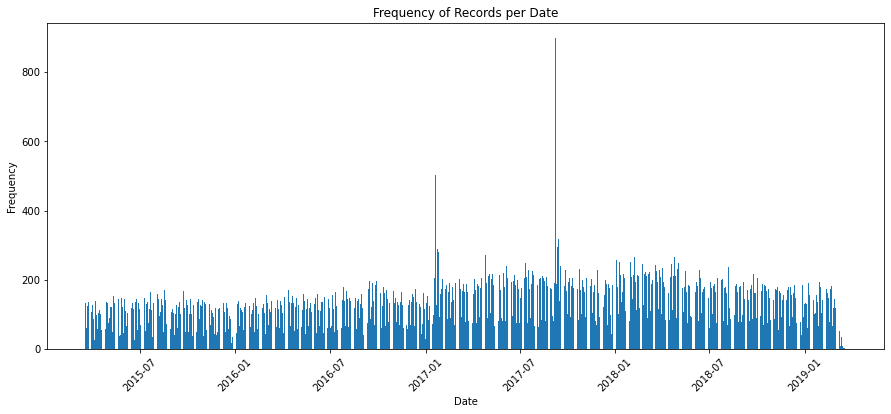

In [7]:
# Convert the date column to a datetime object
df['Date received'] = pd.to_datetime(df['Date received'])
df["Date sent to company"] = pd.to_datetime(df["Date sent to company"])

# Group the data by date and calculate the frequency
date_counts = df.groupby(['Date received']).size().reset_index(name='counts')

# Plot the frequency
plt.figure(figsize=(15, 6))
plt.bar(date_counts['Date received'], date_counts['counts'])
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.title('Frequency of Records per Date')
plt.show()

Total unique values are:  15 


Category	Value

Theft                    19071
Accidental Damage        19023
Online GP                18090
Fire                     17622
Employee Assistance      16159
Accident                 15880
Workplace pension        14481
Private Medical Cover    14294
Mental Health Service    14215
Occupational Health      12559
Personal pension         12075
ISA                       9864
Escape of oil             7070
Flood                     4808
Storm                     4046
Name: Product, dtype: int64


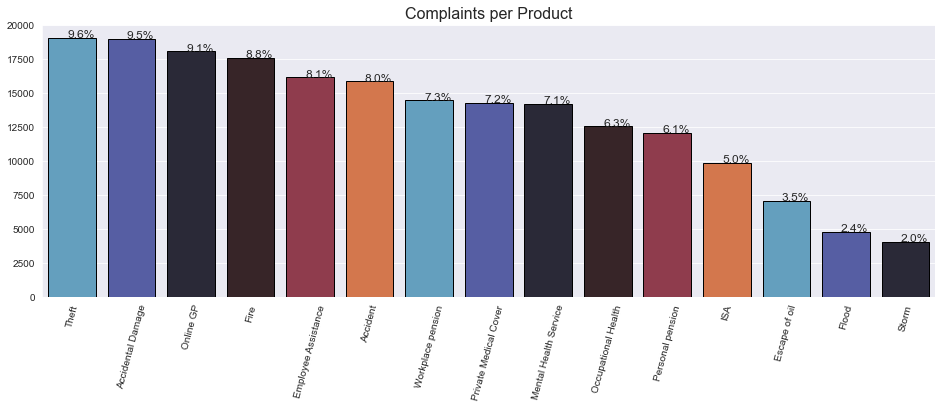

In [8]:
per_on_bar(df["Product"], title="Complaints per Product")

Total unique values are:  4 


Category	Value

Health insurance    75317
Motor insurance     47650
Home insurance      39870
Pension             36420
Name: Product_type, dtype: int64


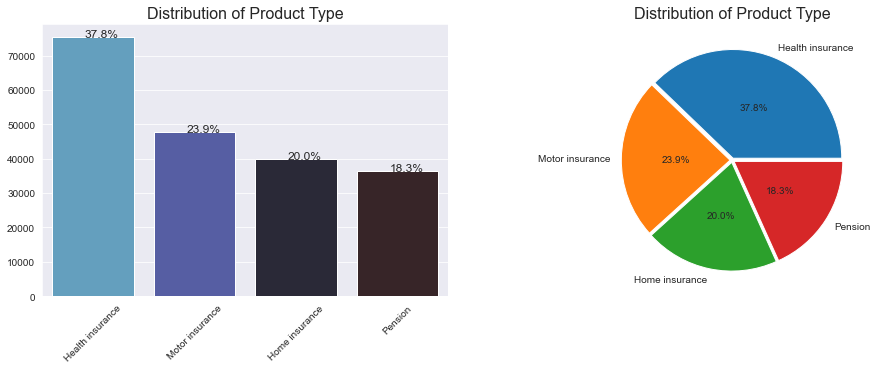

In [9]:
make_plots(df["Product_type"], title="Distribution of Product Type")

Total unique values are:  75 


Category	Value

Credit reporting                              21641
Checking account                              12728
I do not know                                 11973
General-purpose credit card or charge card    11224
Other debt                                     9455
Other (i.e. phone, health club, etc.)          8716
Federal student loan servicing                 8351
Conventional home mortgage                     7906
Credit card debt                               7191
Conventional fixed mortgage                    7007
Medical debt                                   5592
Credit card                                    5307
FHA mortgage                                   5289
Medical                                        4957
Non-federal student loan                       4575
Vehicle loan                                   3660
Installment loan                               3379
Loan                                           3049
Private student 

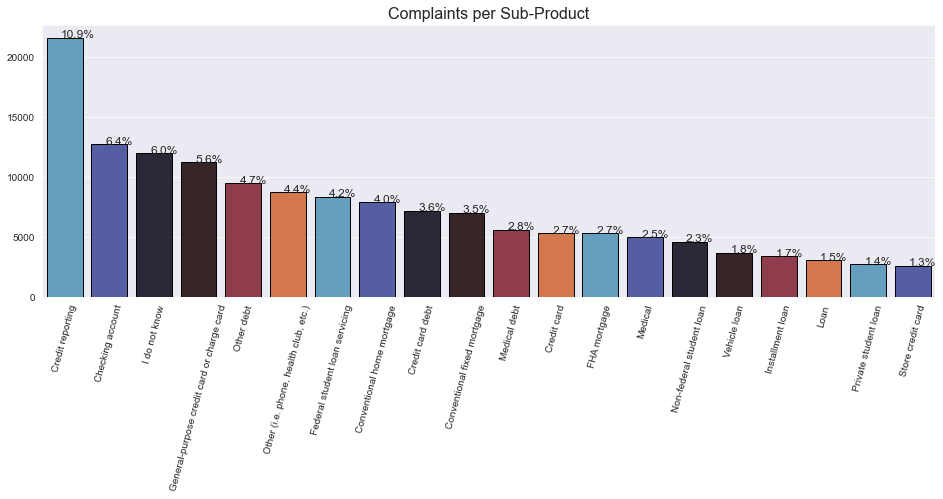

In [10]:
per_on_bar(df["Sub-product"], title="Complaints per Sub-Product", limited=True, n=20)

Total unique values are:  2 


Category	Value

non-vunerable    191870
vunerable          7387
Name: vunerable_customer, dtype: int64


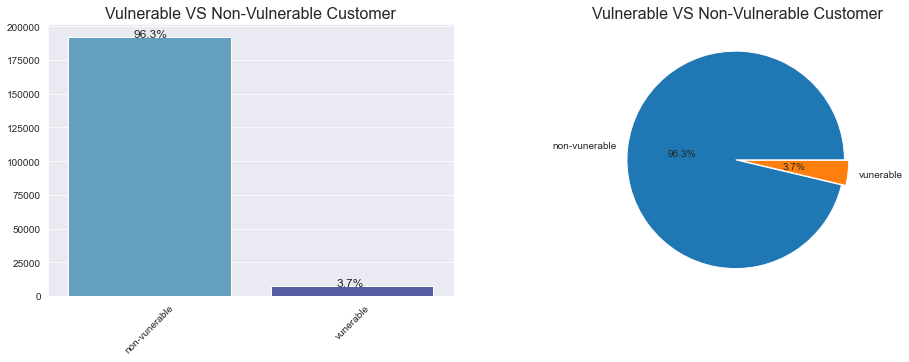

In [11]:
make_plots(df["vunerable_customer"], title="Vulnerable VS Non-Vulnerable Customer", limited=True, n=20)

Total unique values are:  4 


Category	Value

Dec-24    70448
0-3       63108
24+       35745
03-Dec    29956
Name: cancelation_period_month, dtype: int64


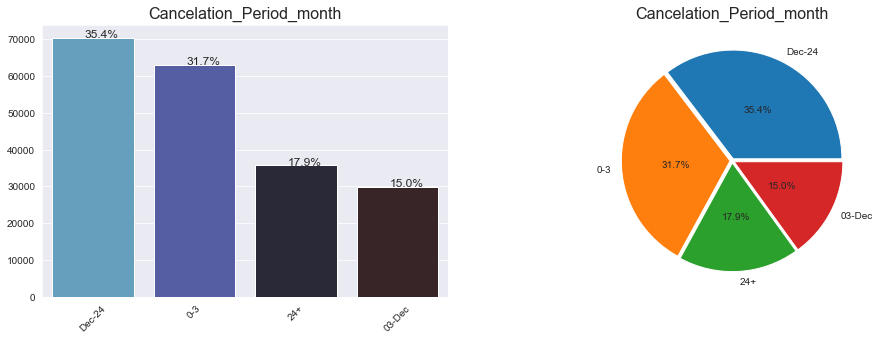

In [12]:
make_plots(df["cancelation_period_month"], title="Cancelation_Period_month", limited=True, n=20)

Total unique values are:  10 


Category	Value

Misselling               69681
Product Functionality    29886
Product Design           29788
Account                  20197
Repayment                19881
Customer Servivce        19781
Fraud                     7027
Credit Reporting          1052
Technical/IT              1012
Other                      952
Name: issue_source, dtype: int64


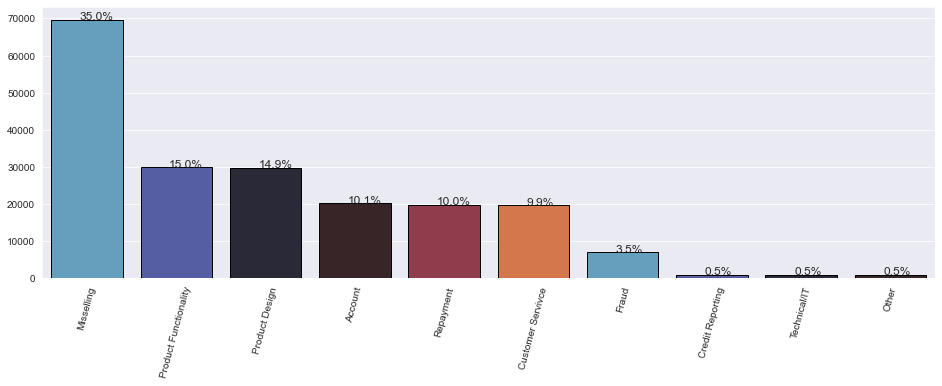

In [13]:
per_on_bar(df["issue_source"], limited=True, n=20)

Total unique values are:  159 


Category	Value

Attempts to collect debt not owed                                                   14045
Cont'd attempts collect debt not owed                                               12340
Problem with a credit reporting company's investigation into an existing problem    11236
Communication tactics                                                                8045
Improper use of your report                                                          7105
Trouble during payment process                                                       6483
Written notification about debt                                                      6477
Loan servicing, payments, escrow account                                             6203
False statements or representation                                                   6044
Dealing with my lender or servicer                                                   5601
Disclosure verification of debt                    

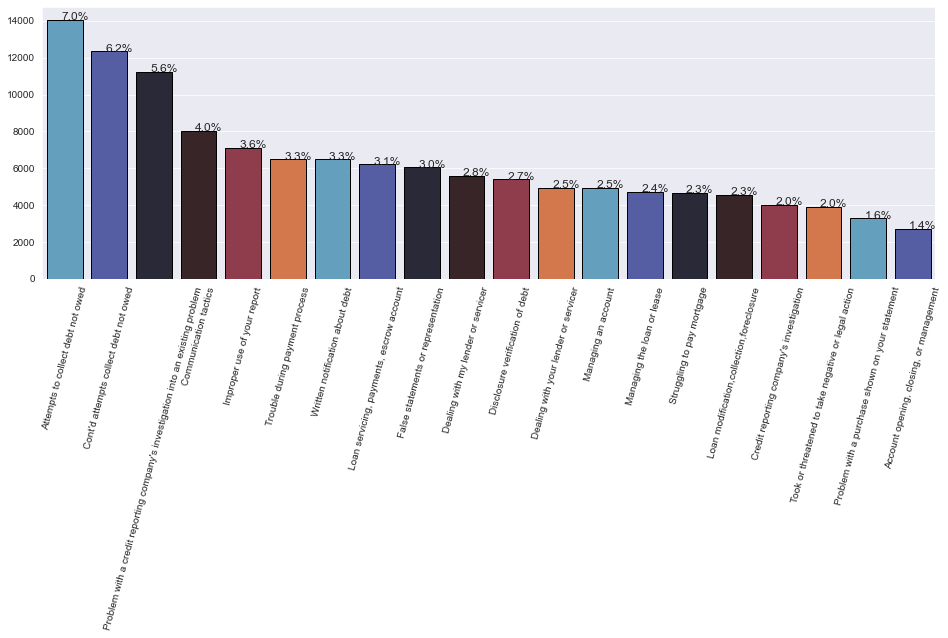

In [14]:
per_on_bar(df["Issue"], limited=True, n=20)

Total unique values are:  200 


Category	Value

Their investigation did not fix an error on your report                             7879
Debt is not yours                                                                   7487
Debt is not mine                                                                    7136
Debt was paid                                                                       6550
Attempted to collect wrong amount                                                   4669
Frequent or repeated calls                                                          4463
Credit inquiries on your report that you don't recognize                            4383
Didn't receive enough information to verify debt                                    4031
Not given enough info to verify debt                                                3152
Debt was result of identity theft                                                   2596
Reporting company used your report improperly                

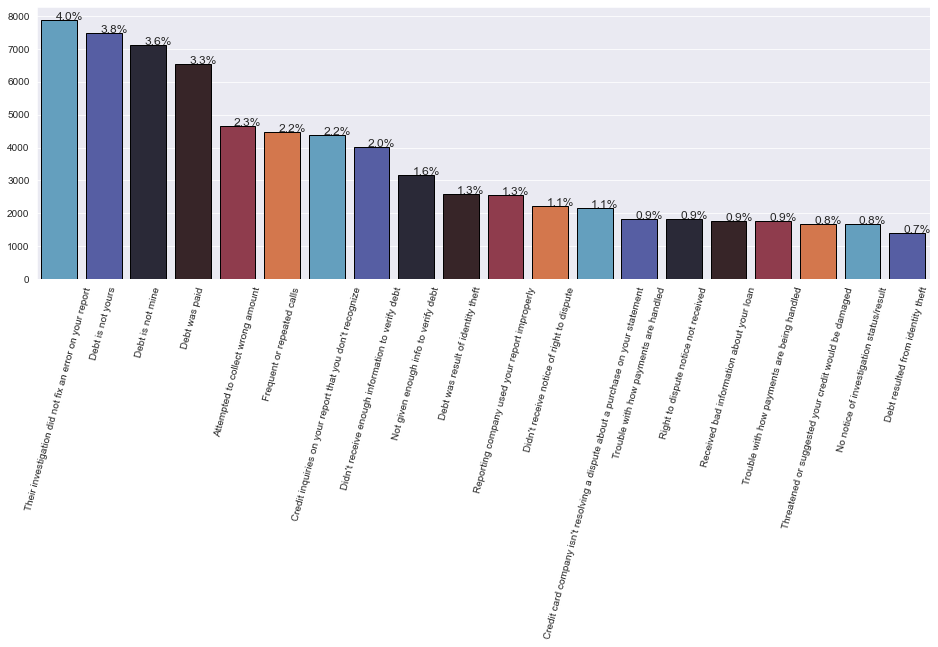

In [15]:
per_on_bar(df["Sub-issue"], limited=True, n=20)

In [16]:
def plot_wordcloud(text, title=""):
    from wordcloud import WordCloud
    # Generating WordCloud
    comment_words = ''
    stopwords = list(nltk.corpus.stopwords.words("english"))
    stopwords.append("XX")
    stopwords.append("XXXX")

    # iterate through the csv file
    for val in text:
        # typecaste each val to string
        val = str(val)
        # split the value
        tokens = val.split()

        # Converts each token into lowercase
        for i in range(len(tokens)):
            tokens[i] = tokens[i].lower()

        comment_words += " ".join(tokens)+" "

    wordcloud = WordCloud(width = 1200, height = 700, background_color ='black',
          stopwords = stopwords,
          min_font_size = 10).generate(comment_words)

    # plot the WordCloud image
    plt.figure(figsize = (12, 7), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout(pad = 0)
    plt.show()

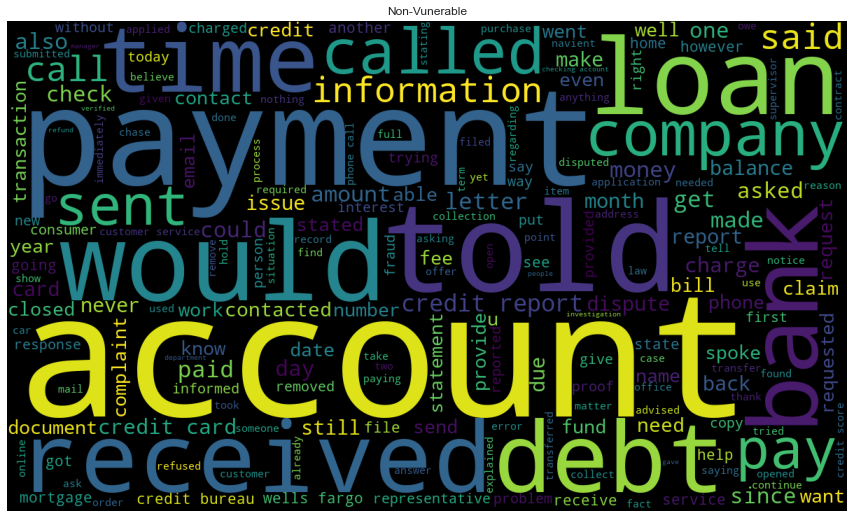

In [17]:
temp = df[df["vunerable_customer"] == "non-vunerable"]["Consumer complaint narrative"].iloc[:10000]
plot_wordcloud(temp, title="Non-Vunerable")

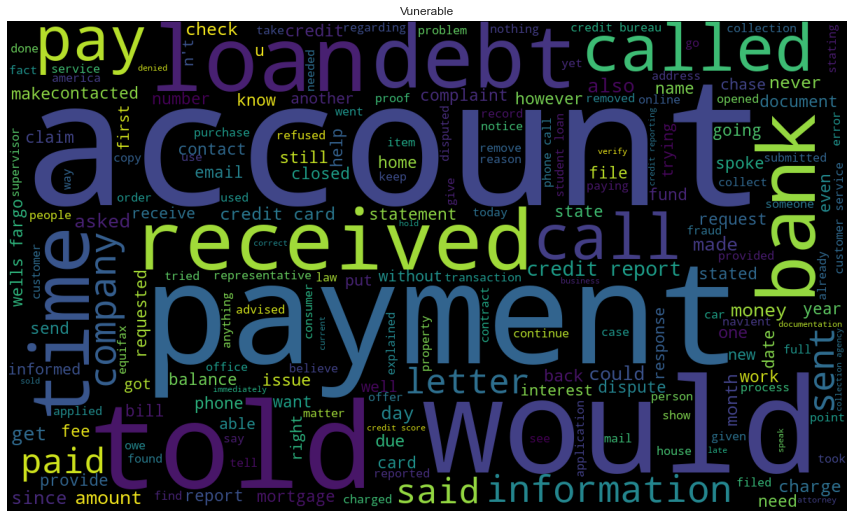

In [18]:
temp = df[df["vunerable_customer"] == "vunerable"]["Consumer complaint narrative"].iloc[:10000]
plot_wordcloud(temp, title="Vunerable")

Total unique values are:  10 


Category	Value

Company has responded to the consumer and the CFPB and chooses not to provide a public response                            54746
Company believes it acted appropriately as authorized by contract or law                                                   17280
Company chooses not to provide a public response                                                                            9238
Company disputes the facts presented in the complaint                                                                       1768
Company believes the complaint is the result of a misunderstanding                                                          1700
Company believes complaint caused principally by actions of third party outside the control or direction of the company     1226
Company believes complaint is the result of an isolated error                                                               1116
Company believes complaint represents an opportun

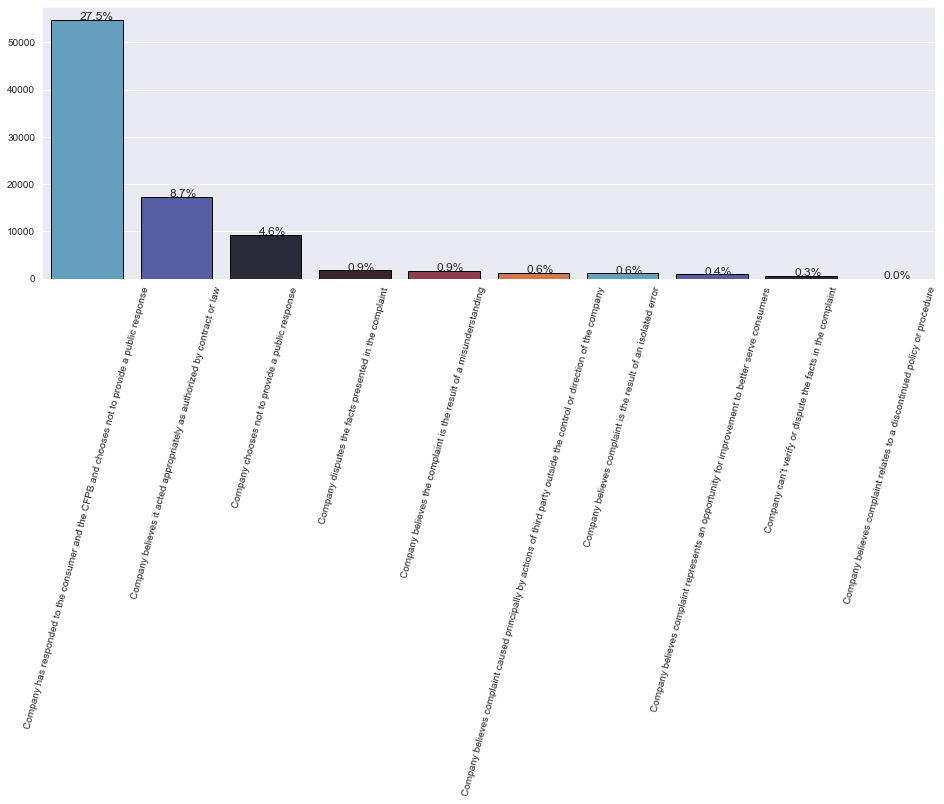

In [19]:
per_on_bar(df["Company public response"])

Total unique values are:  2 


Category	Value

Yes    192318
No       6939
Name: Timely response?, dtype: int64


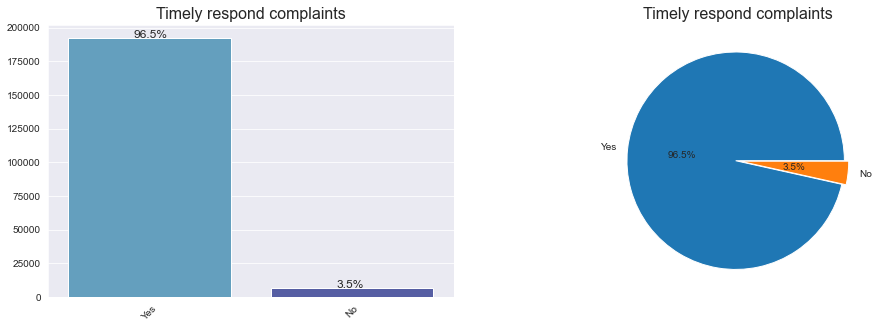

In [20]:
make_plots(df["Timely response?"], title="Timely respond complaints")

Total unique values are:  2 


Category	Value

Female    103444
Male       95813
Name: gender_cat, dtype: int64


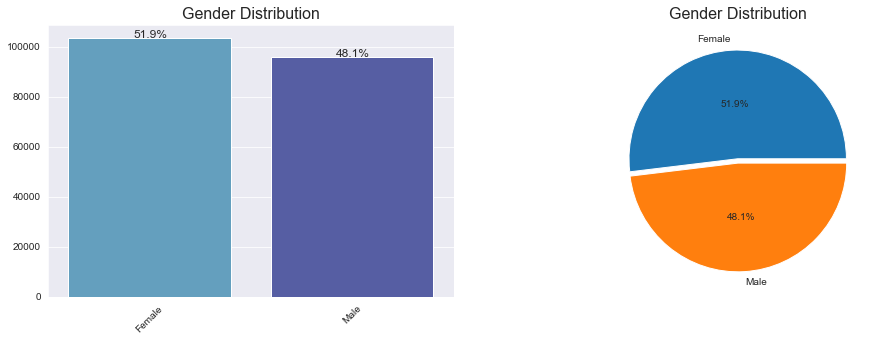

In [21]:
make_plots(df["gender_cat"], title="Gender Distribution")

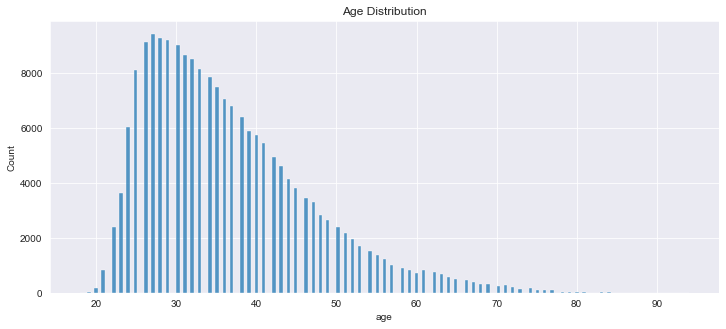

In [22]:
plt.figure(figsize=(12, 5))
sns.histplot(df["age"])
plt.title("Age Distribution")
plt.show()

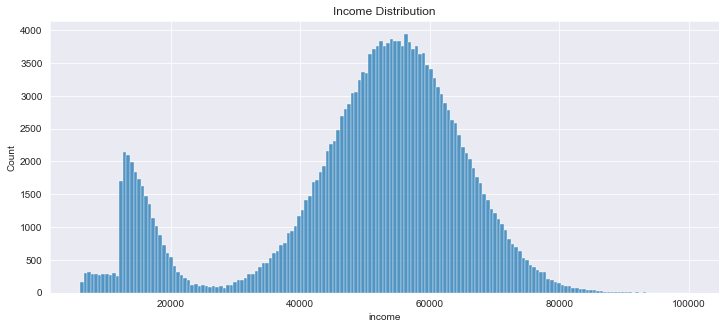

In [23]:
plt.figure(figsize=(12, 5))
sns.histplot(df["income"])
plt.title("Income Distribution")
plt.show()

Total unique values are:  8 


Category	Value

0    102514
1     57657
2     27085
3      9540
4      2139
5       304
6        17
7         1
Name: children, dtype: int64


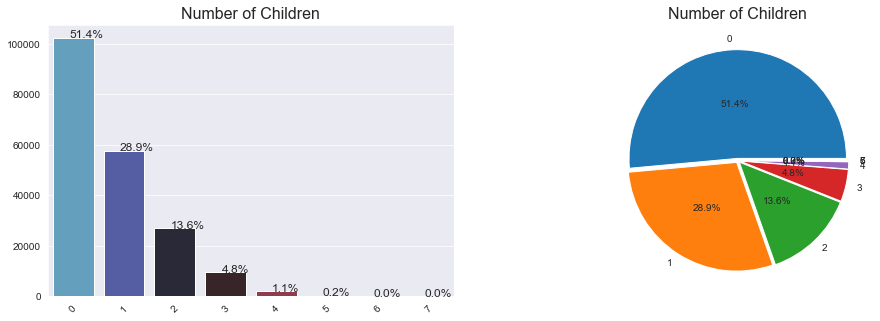

In [24]:
make_plots(df["children"], title="Number of Children")

Total unique values are:  14 


Category	Value

Mental health                          24021
Income Shock                           23806
 Low or erratic income                 23739
Bereavement                            18059
Caring responsibilities                17773
hard of hearing                        15938
Over indebtedness                      15765
learning difficulties                  12024
chronic health issues                  11960
Auto Immune Diseases                    8078
Poor or non-existent digital skills     8053
poor eyesight                           7968
Low knowledge of financial matters      6062
Low English language skills             6011
Name: vulnerability category, dtype: int64


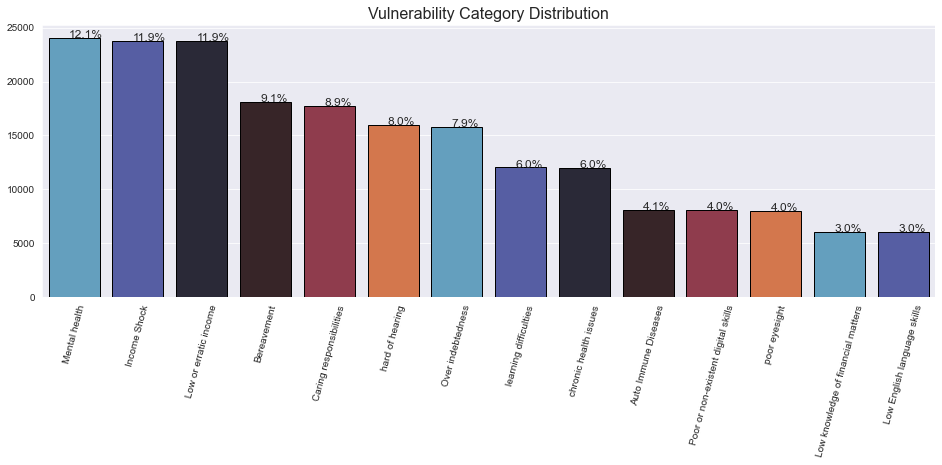

In [25]:
per_on_bar(df["vulnerability category"], title="Vulnerability Category Distribution")

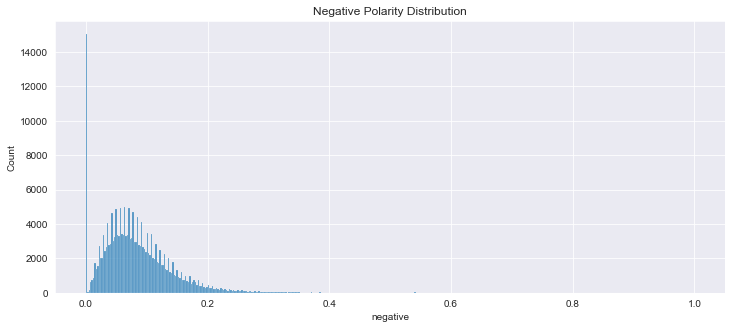

In [26]:
plt.figure(figsize=(12, 5))
sns.histplot(df["negative"])
plt.title("Negative Polarity Distribution")
plt.show()

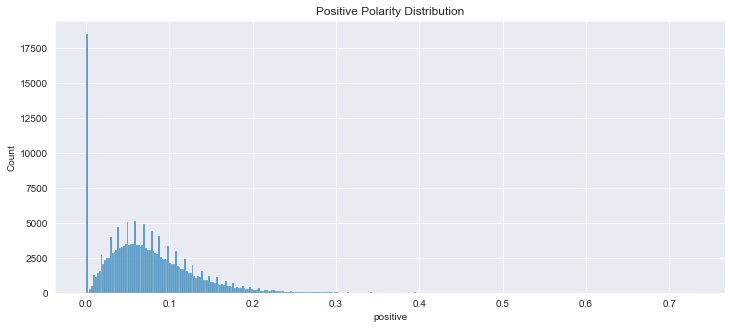

In [27]:
plt.figure(figsize=(12, 5))
sns.histplot(df["positive"])
plt.title("Positive Polarity Distribution")
plt.show()

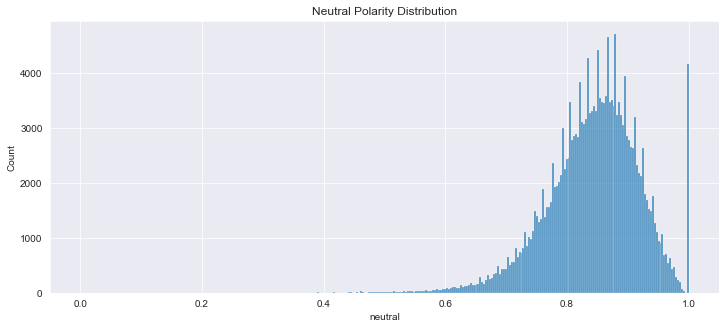

In [28]:
plt.figure(figsize=(12, 5))
sns.histplot(df["neutral"])
plt.title("Neutral Polarity Distribution")
plt.show()

Total unique values are:  3 


Category	Value

neutral     179119
negative     14259
positive      5879
Name: sentiment, dtype: int64


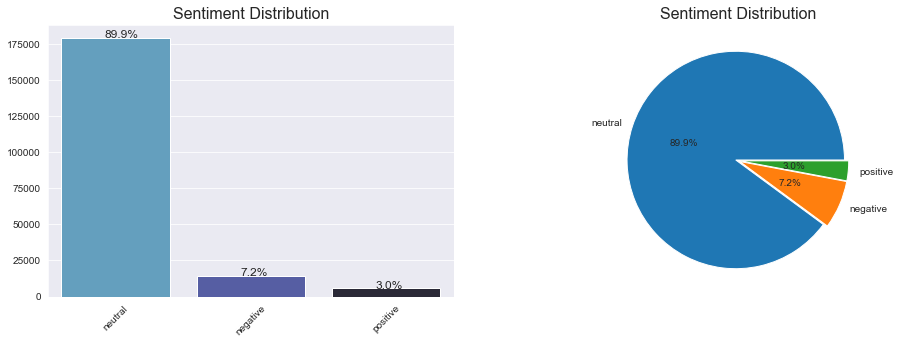

In [29]:
make_plots(df["sentiment"], title="Sentiment Distribution")

Total unique values are:  5 


Category	Value

Mobile App              61764
Chatbot                 60102
Online Surveys          31844
Online Feedback Form    30117
Phone Call              15430
Name: Channel_of_communication, dtype: int64


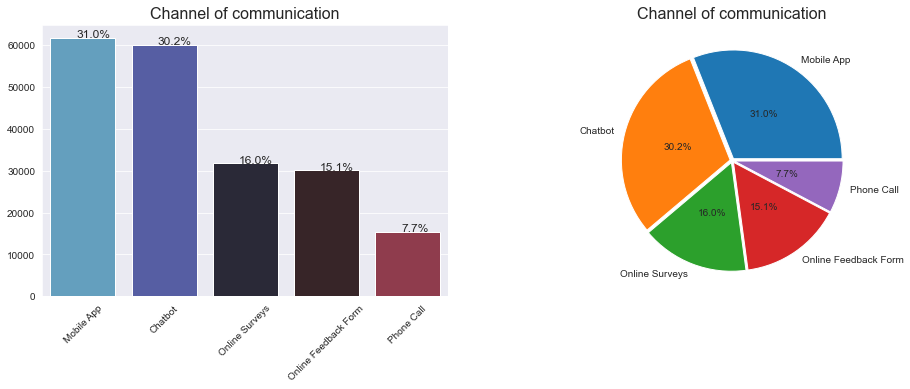

In [30]:
make_plots(df["Channel_of_communication"], title="Channel of communication")

Total unique values are:  8 


Category	Value

student         30466
entrepreneur    27375
unemployed      27335
services        27054
housemaid       27015
management      26886
blue collar     26713
retired          6413
Name: job, dtype: int64


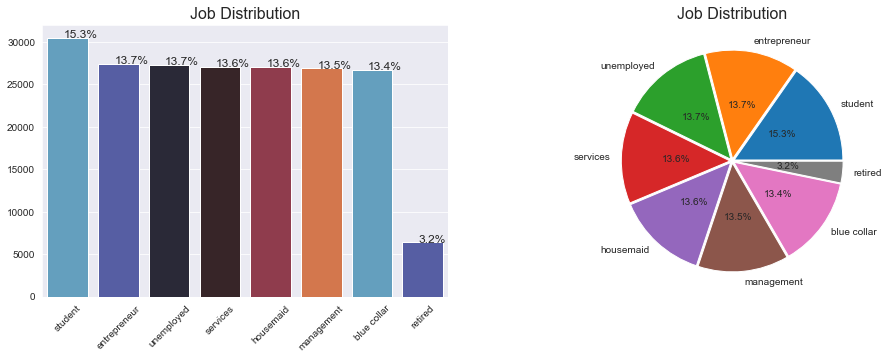

In [31]:
make_plots(df["job"], title="Job Distribution")

Total unique values are:  3 


Category	Value

secondary    105195
tertiary      55467
primary       38595
Name: education, dtype: int64


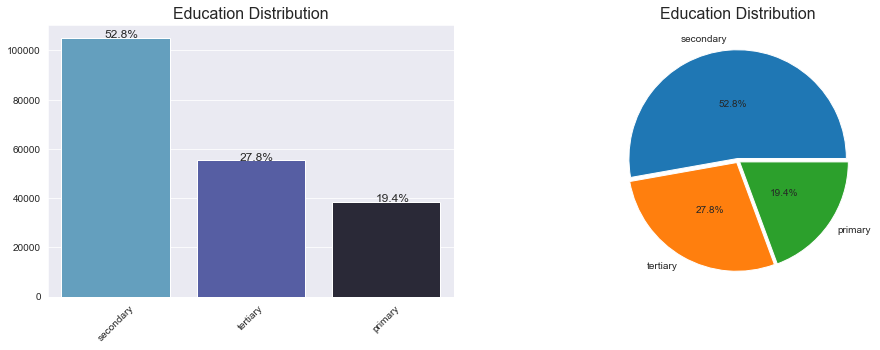

In [32]:
make_plots(df["education"], title="Education Distribution")

Total unique values are:  17 


Category	Value

0     191870
28      1433
32      1295
36      1192
40       878
24       839
20       339
30       283
44       230
34       228
38       190
26       168
42       118
16        97
22        68
18        20
48         9
Name: vulnerability_score, dtype: int64


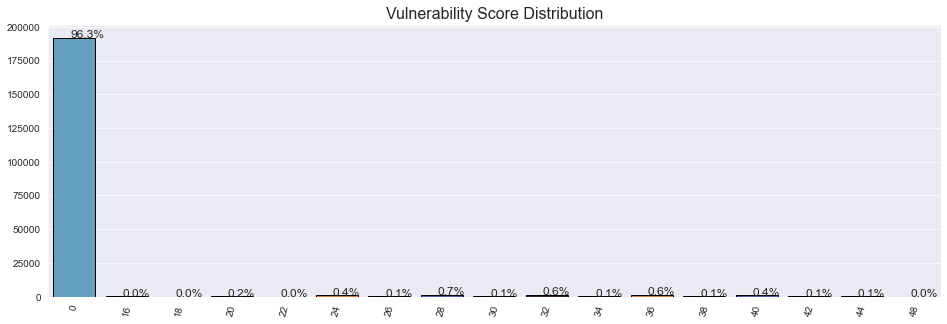

In [33]:
per_on_bar(df["vulnerability_score"], title="Vulnerability Score Distribution")

Total unique values are:  5 


Category	Value

Level 0 - not vulnerable            191870
Level 3 - moderate vulnerability      3188
Level 2 - mild vulnerability          2847
Level 4 - high vulnerability          1235
Level 1 - vulnerability prone          117
Name: vulnerability_level, dtype: int64


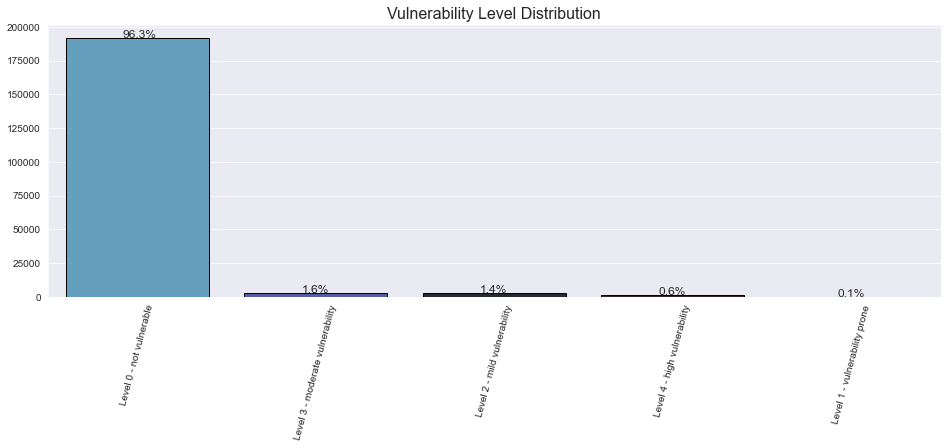

In [34]:
per_on_bar(df["vulnerability_level"], title="Vulnerability Level Distribution")

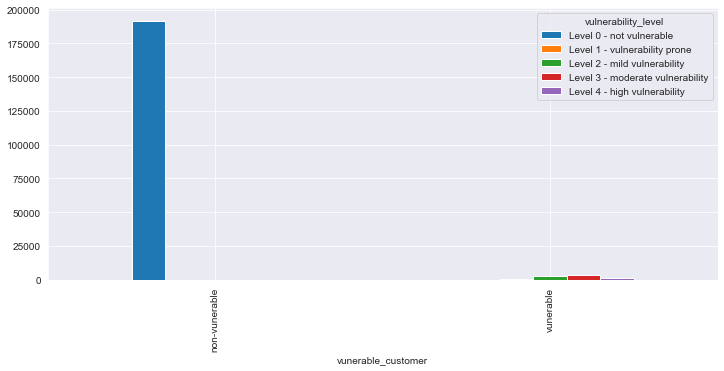

In [35]:
pd.crosstab(df["vunerable_customer"], df["vulnerability_level"]).plot(kind="bar", figsize=(12, 5))
plt.show()

In [36]:
def make_crosstab(feature_name, target_name="vunerable_customer", target_value="vunerable"):
    # Code to get a random color map for graph
    rand = np.random.randint(1, 30)
    color_maps = ['binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 
                  'coolwarm_r', 'copper', 'copper_r', 'crest', 'crest_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'flare', 'flare_r', 
                  'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 
                  'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'hot', 'hot_r']

    # Making crosstab and then plotting it in form of bar chart
    pd.crosstab(df[feature_name], df[target_name]).plot(kind="bar", cmap=color_maps[rand], stacked=False, figsize=(14, 5))
    plt.show()

    # Calculating the ratio of being diabetic for each unique value of feature
    data = {}
    for i in df[feature_name].unique():
        nomer = df[((df[target_name] == target_value) & (df[feature_name] == i))]
        denom = df[(df[feature_name] == i)]
        try:
            rate = 100*(len(nomer)/len(denom))
        except:
            rate = 0
        data[i] = rate
    
    # Sorting values according to ratio
    data = dict(sorted(data.items(), reverse=True, key=lambda item: item[1]))
    
    # Printing top 3 categories with their ratio
    top = 3
    for i, j in data.items():
        if top > 0:
            print(f"Vulnerability Rate for category {str(i).upper()} in variable {str(feature_name).upper()} is {j}")
            top -= 1
        else:
            break

                                                   PRODUCT                                              


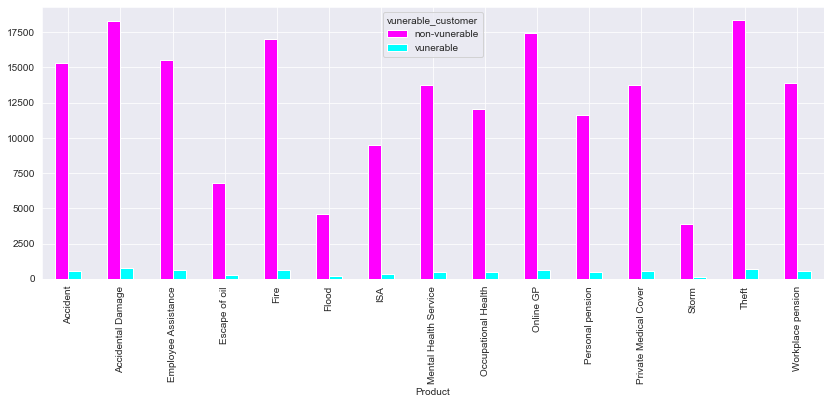

Vulnerability Rate for category EMPLOYEE ASSISTANCE in variable PRODUCT is 3.9420756234915526
Vulnerability Rate for category STORM in variable PRODUCT is 3.9050914483440433
Vulnerability Rate for category OCCUPATIONAL HEALTH in variable PRODUCT is 3.9015845210605944
                                                   CANCELATION_PERIOD_MONTH                                              


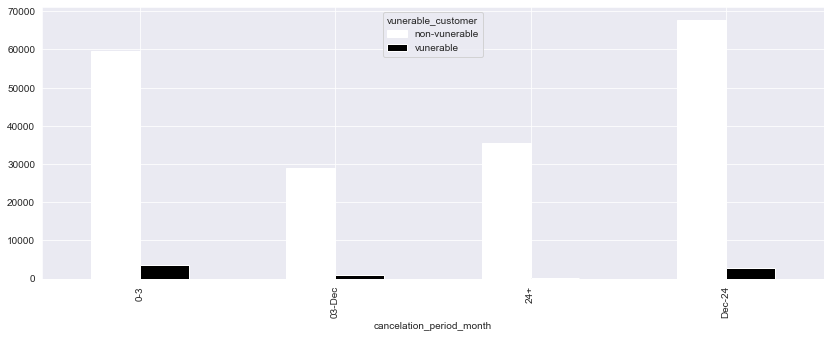

Vulnerability Rate for category 0-3 in variable CANCELATION_PERIOD_MONTH is 5.725106167205426
Vulnerability Rate for category DEC-24 in variable CANCELATION_PERIOD_MONTH is 3.7602203043379516
Vulnerability Rate for category 03-DEC in variable CANCELATION_PERIOD_MONTH is 3.08118573908399
                                                   ISSUE_SOURCE                                              


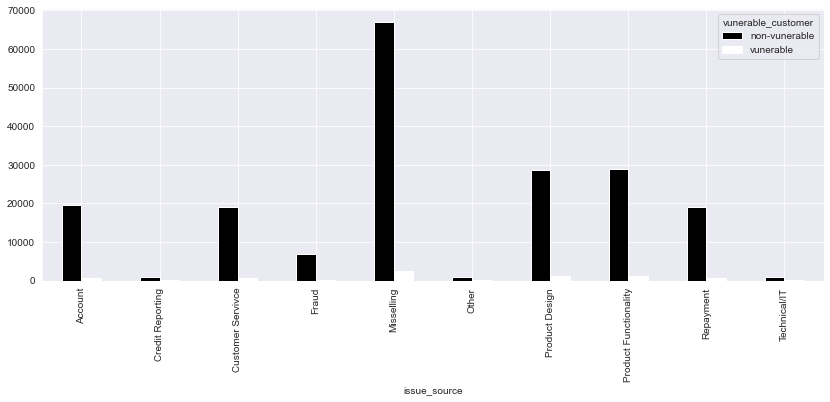

Vulnerability Rate for category REPAYMENT in variable ISSUE_SOURCE is 3.8126854785976563
Vulnerability Rate for category PRODUCT DESIGN in variable ISSUE_SOURCE is 3.7498321471733584
Vulnerability Rate for category MISSELLING in variable ISSUE_SOURCE is 3.7212439545930747
                                                   COMPANY PUBLIC RESPONSE                                              


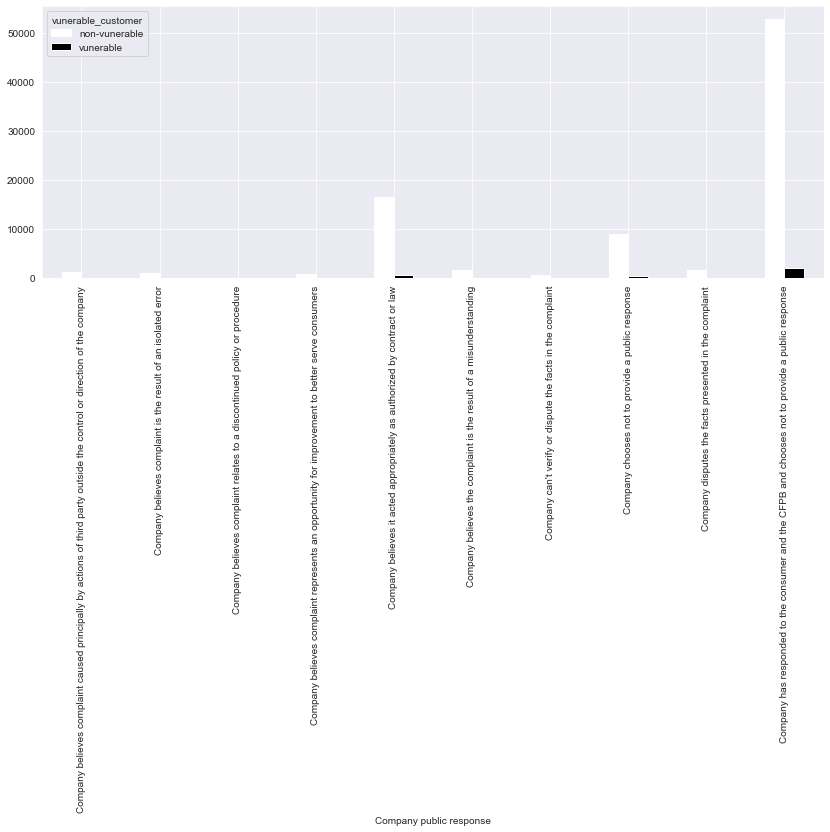

Vulnerability Rate for category COMPANY BELIEVES COMPLAINT RELATES TO A DISCONTINUED POLICY OR PROCEDURE in variable COMPANY PUBLIC RESPONSE is 6.25
Vulnerability Rate for category COMPANY BELIEVES COMPLAINT REPRESENTS AN OPPORTUNITY FOR IMPROVEMENT TO BETTER SERVE CONSUMERS in variable COMPANY PUBLIC RESPONSE is 4.377104377104377
Vulnerability Rate for category COMPANY BELIEVES COMPLAINT IS THE RESULT OF AN ISOLATED ERROR in variable COMPANY PUBLIC RESPONSE is 4.032258064516129
                                                   COMPANY RESPONSE TO CONSUMER                                              


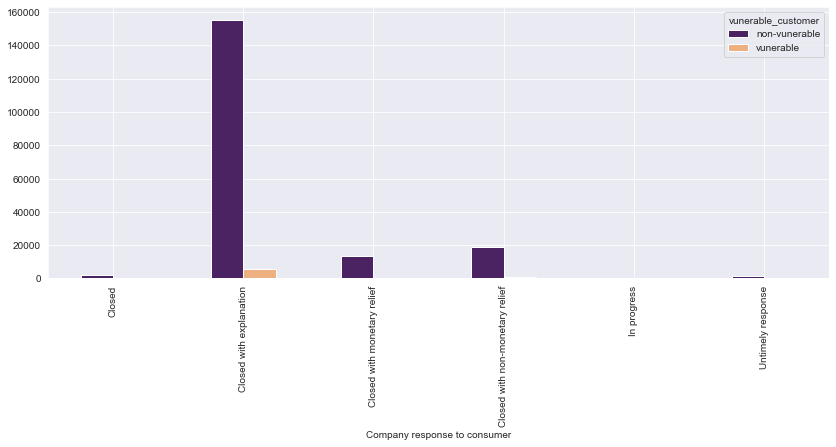

Vulnerability Rate for category CLOSED in variable COMPANY RESPONSE TO CONSUMER is 4.286926994906621
Vulnerability Rate for category UNTIMELY RESPONSE in variable COMPANY RESPONSE TO CONSUMER is 4.044803982576229
Vulnerability Rate for category CLOSED WITH MONETARY RELIEF in variable COMPANY RESPONSE TO CONSUMER is 3.864426008650642
                                                   TIMELY RESPONSE?                                              


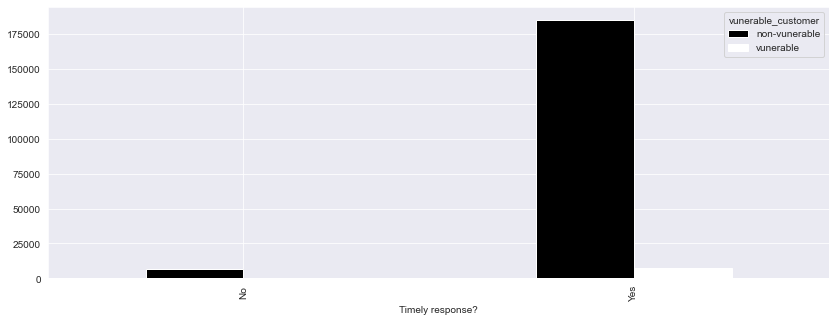

Vulnerability Rate for category NO in variable TIMELY RESPONSE? is 4.035163568237498
Vulnerability Rate for category YES in variable TIMELY RESPONSE? is 3.6954419243128567
                                                   CONSUMER DISPUTED?                                              


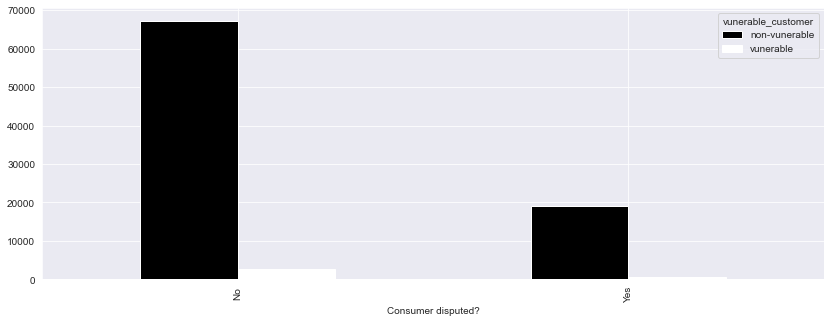

Vulnerability Rate for category NO in variable CONSUMER DISPUTED? is 3.7015301375549288
Vulnerability Rate for category YES in variable CONSUMER DISPUTED? is 3.6053902873124843
Vulnerability Rate for category NAN in variable CONSUMER DISPUTED? is 0
                                                   GENDER_CAT                                              


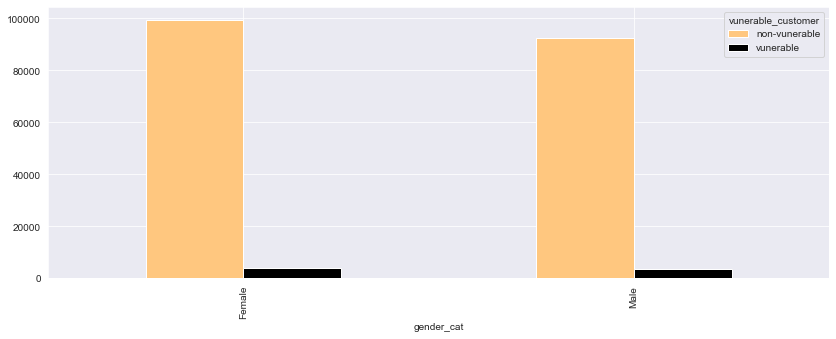

Vulnerability Rate for category FEMALE in variable GENDER_CAT is 3.7440547542631766
Vulnerability Rate for category MALE in variable GENDER_CAT is 3.667560769415424
                                                   RECOMMENDED PATHWAY SWITCH                                              


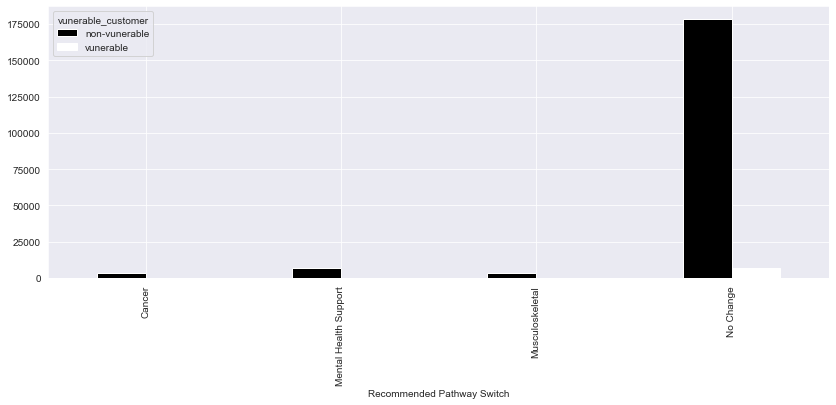

Vulnerability Rate for category MUSCULOSKELETAL in variable RECOMMENDED PATHWAY SWITCH is 4.120488775220233
Vulnerability Rate for category CANCER in variable RECOMMENDED PATHWAY SWITCH is 3.8097966198796906
Vulnerability Rate for category MENTAL HEALTH SUPPORT in variable RECOMMENDED PATHWAY SWITCH is 3.764274636966023
                                                   VULNERABILITY CATEGORY                                              


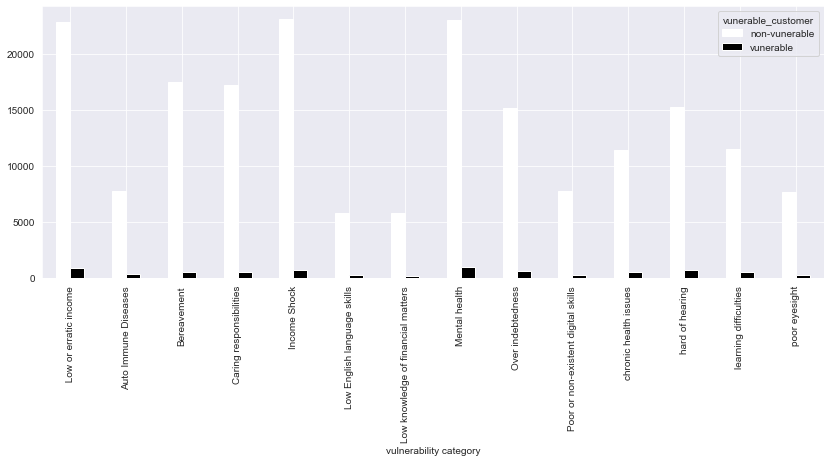

Vulnerability Rate for category HARD OF HEARING in variable VULNERABILITY CATEGORY is 4.316727318358639
Vulnerability Rate for category LEARNING DIFFICULTIES in variable VULNERABILITY CATEGORY is 4.241516966067864
Vulnerability Rate for category CHRONIC HEALTH ISSUES in variable VULNERABILITY CATEGORY is 4.205685618729097
                                                   VULNERABILITY TYPE                                              


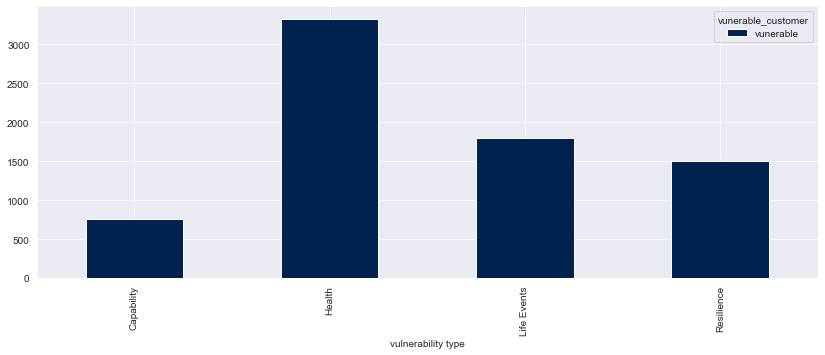

Vulnerability Rate for category CAPABILITY in variable VULNERABILITY TYPE is 100.0
Vulnerability Rate for category HEALTH in variable VULNERABILITY TYPE is 100.0
Vulnerability Rate for category LIFE EVENTS in variable VULNERABILITY TYPE is 100.0
                                                   SENTIMENT                                              


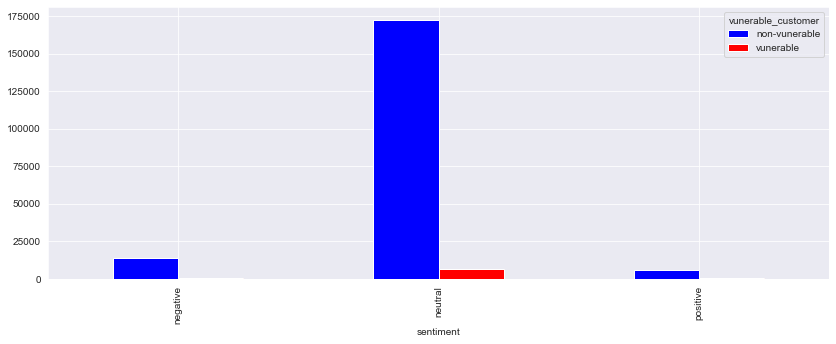

Vulnerability Rate for category POSITIVE in variable SENTIMENT is 3.7421330158190167
Vulnerability Rate for category NEGATIVE in variable SENTIMENT is 3.709937583280735
Vulnerability Rate for category NEUTRAL in variable SENTIMENT is 3.7059161786298493
                                                   CHANNEL_OF_COMMUNICATION                                              


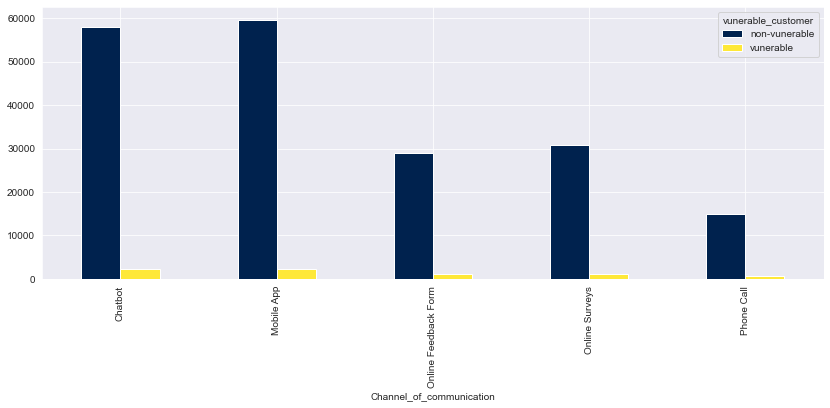

Vulnerability Rate for category ONLINE FEEDBACK FORM in variable CHANNEL_OF_COMMUNICATION is 3.9711790683002954
Vulnerability Rate for category PHONE CALL in variable CHANNEL_OF_COMMUNICATION is 3.882047958522359
Vulnerability Rate for category CHATBOT in variable CHANNEL_OF_COMMUNICATION is 3.717014408838308
                                                   JOB                                              


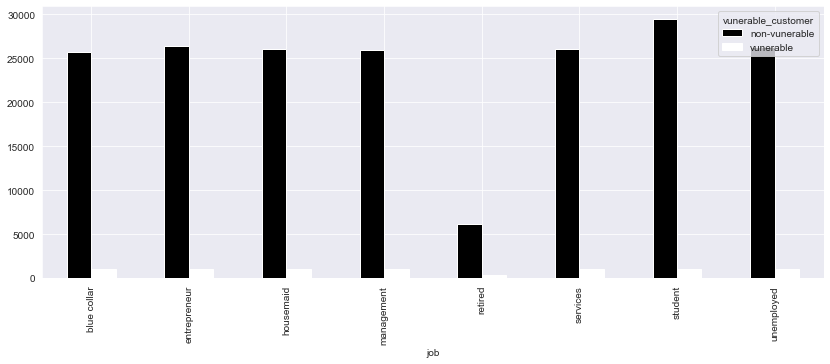

Vulnerability Rate for category RETIRED in variable JOB is 4.537657882426322
Vulnerability Rate for category BLUE COLLAR in variable JOB is 3.837083068169056
Vulnerability Rate for category SERVICES in variable JOB is 3.781326236416057
                                                   EDUCATION                                              


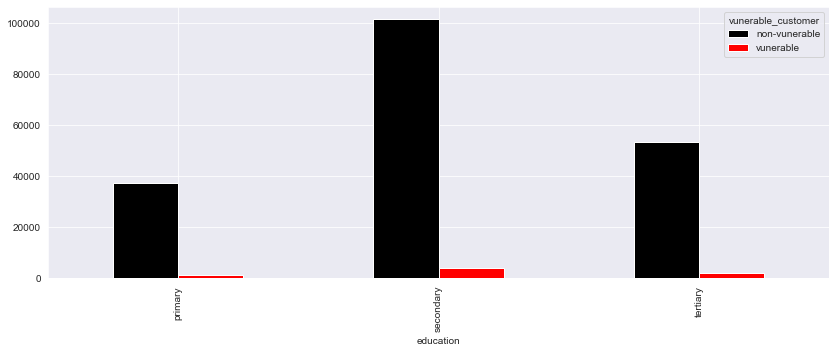

Vulnerability Rate for category PRIMARY in variable EDUCATION is 3.7414172820313514
Vulnerability Rate for category TERTIARY in variable EDUCATION is 3.699496998215155
Vulnerability Rate for category SECONDARY in variable EDUCATION is 3.698845002138885
                                                   VULNERABILITY_LEVEL                                              


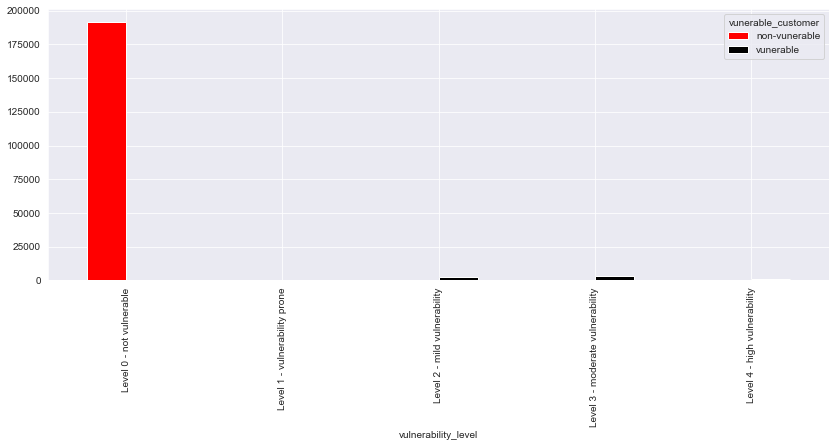

Vulnerability Rate for category LEVEL 2 - MILD VULNERABILITY in variable VULNERABILITY_LEVEL is 100.0
Vulnerability Rate for category LEVEL 3 - MODERATE VULNERABILITY in variable VULNERABILITY_LEVEL is 100.0
Vulnerability Rate for category LEVEL 4 - HIGH VULNERABILITY in variable VULNERABILITY_LEVEL is 100.0
                                                   VULNERABILITY SOURCE                                              


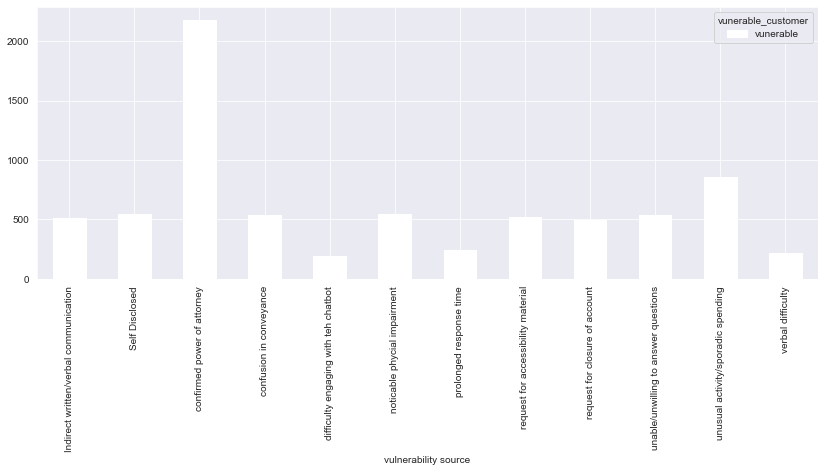

Vulnerability Rate for category CONFIRMED POWER OF ATTORNEY in variable VULNERABILITY SOURCE is 100.0
Vulnerability Rate for category SELF DISCLOSED in variable VULNERABILITY SOURCE is 100.0
Vulnerability Rate for category UNABLE/UNWILLING TO ANSWER QUESTIONS in variable VULNERABILITY SOURCE is 100.0
                                                   HIGH LEVEL ISSUE                                              


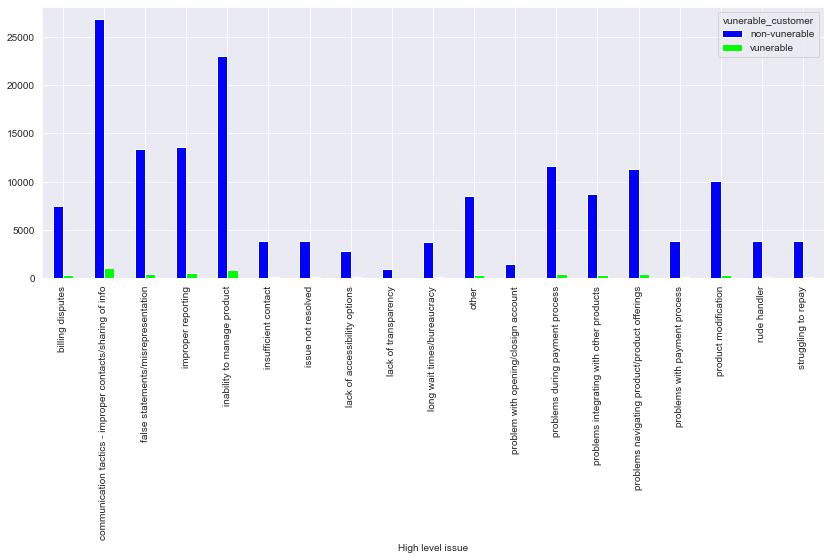

Vulnerability Rate for category OTHER in variable HIGH LEVEL ISSUE is 4.085297418630752
Vulnerability Rate for category ISSUE NOT RESOLVED in variable HIGH LEVEL ISSUE is 4.069478908188586
Vulnerability Rate for category BILLING DISPUTES in variable HIGH LEVEL ISSUE is 4.021961184882533
                                                   PRODUCT_TYPE                                              


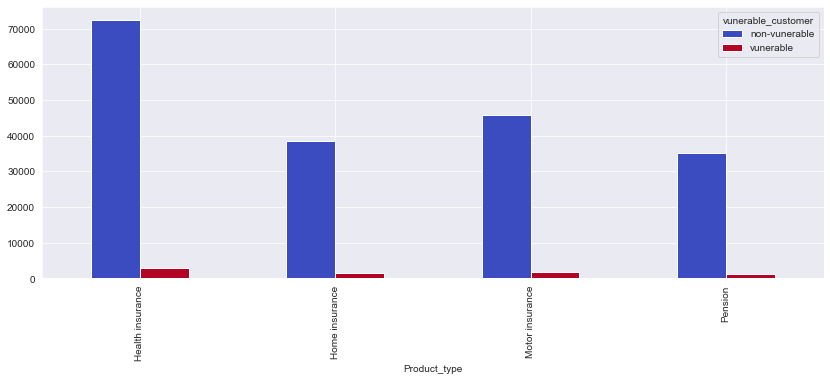

Vulnerability Rate for category PENSION in variable PRODUCT_TYPE is 3.747940691927512
Vulnerability Rate for category MOTOR INSURANCE in variable PRODUCT_TYPE is 3.7439664218258133
Vulnerability Rate for category HEALTH INSURANCE in variable PRODUCT_TYPE is 3.7096538630056957


In [37]:
cols = ["Issue", "Sub-product", "Sub-issue", "Consumer complaint narrative", "State", "vunerable_customer"]
for col in df.select_dtypes("O").drop(cols, axis=1).columns:
    print("="*120)
    print(" "*50, str(col).upper(), " "*45)
    print("="*120)
    
    make_crosstab(col)

# Data Preparation

In [38]:
df[df.duplicated(subset=["Feedback ID"])]

,Feedback ID,Date received,Product,Sub-product,vunerable_customer,cancelation_period_month,issue_source,Issue,Sub-issue,Consumer complaint narrative,Company public response,State,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,gender_cat,age,rejected,Recommended Pathway Switch,income,children,vulnerability category,vulnerability type,negative,positive,neutral,sentiment,Channel_of_communication,job,education,cust_ID,product_ID,vulnerability_score,vulnerability_level,vulnerability source,Self Disclosed Vulnerability,escalated to ombudsman,High level issue,Product_type,Claims_Aging


In [39]:
temp = df.isnull().sum().to_frame()
temp["Percentage"] = (df.isnull().sum()/len(df)).round(3)
temp.columns = ["Null Values", "Percentage"]
temp.T

,Feedback ID,Date received,Product,Sub-product,vunerable_customer,cancelation_period_month,issue_source,Issue,Sub-issue,Consumer complaint narrative,Company public response,State,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,gender_cat,age,rejected,Recommended Pathway Switch,income,children,vulnerability category,vulnerability type,negative,positive,neutral,sentiment,Channel_of_communication,job,education,cust_ID,product_ID,vulnerability_score,vulnerability_level,vulnerability source,Self Disclosed Vulnerability,escalated to ombudsman,High level issue,Product_type,Claims_Aging
Null Values,0.0,0.0,0.0,21060.000,0.0,0.0,0.0,0.0,67376.000,0.0,110633.000,845.000,0.0,3.0,0.0,109729.000,0.0,2118.000,0.0,0.0,0.0,0.0,0.0,191870.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,191870.000,0.0,0.0,30240.000,0.0,115395.000
Percentage,0.0,0.0,0.0,0.106,0.0,0.0,0.0,0.0,0.338,0.0,0.555,0.004,0.0,0.0,0.0,0.551,0.0,0.011,0.0,0.0,0.0,0.0,0.0,0.963,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.963,0.0,0.0,0.152,0.0,0.579


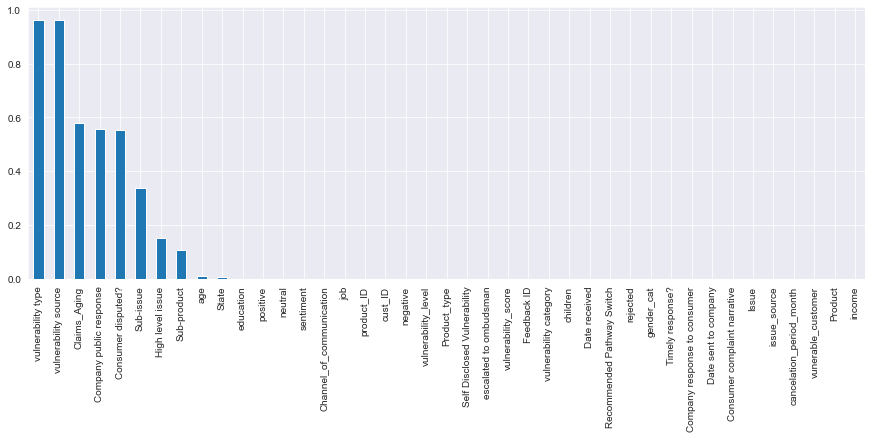

In [40]:
temp.Percentage.sort_values(ascending=False).plot(kind="bar", figsize=(15, 5))
plt.show()

In [41]:
# Columns having more than 50% Null values
temp[temp.Percentage > 0.5]

,Null Values,Percentage
Company public response,110633,0.555
Consumer disputed?,109729,0.551
vulnerability type,191870,0.963
vulnerability source,191870,0.963
Claims_Aging,115395,0.579


In [42]:
df.drop(temp[temp.Percentage > 0.5].index, axis=1, inplace=True)

In [43]:
temp = df.isnull().sum().to_frame()
temp["Percentage"] = (df.isnull().sum()/len(df)).round(3)
temp["Data Type"] = df.dtypes
temp.columns = ["Null Values", "Percentage","Data Type"]
temp.sort_values(by="Percentage", ascending=False)

,Null Values,Percentage,Data Type
Sub-issue,67376,0.338,object
High level issue,30240,0.152,object
Sub-product,21060,0.106,object
age,2118,0.011,float64
State,845,0.004,object
education,0,0.000,object
positive,0,0.000,float64
neutral,0,0.000,float64
sentiment,0,0.000,object
Channel_of_communication,0,0.000,object


In [44]:
df['Sub-issue'] = df['Sub-issue'].fillna(df['Sub-issue'].mode()[0])
df['High level issue'] = df['High level issue'].fillna(df['High level issue'].mode()[0])
df['Sub-product'] = df['Sub-product'].fillna(df['Sub-product'].mode()[0])
df['State'] = df['State'].fillna(df['State'].mode()[0])
df['age'] = df['age'].fillna(df.groupby('vulnerability_level')['age'].transform('mean'))

Data exploration ends here 